# ADM Visualisation
Renders each ADM and every ablation variant separately.

| Section | Variants shown |
|---|---|
| **Preconditions** | `adm_initial()` |
| **Main ADM — full** | `adm_main(True, True)` |
| **Main ADM — no Sub-ADM 1** | `adm_main(False, True)` |
| **Main ADM — no Sub-ADM 2** | `adm_main(True, False)` |
| **Main ADM — no sub-ADMs** | `adm_main(False, False)` |
| **Sub-ADM 1** | `sub_adm_1("example_feature")` |
| **Sub-ADM 2** | `sub_adm_2("example_problem")` |

Graphs are written to `./adm_viz/` and displayed inline.

In [1]:
import sys, io
from contextlib import redirect_stdout
from pathlib import Path
from IPython.display import display, SVG
import pydot

# Notebook lives in Analysis/; ADM modules are one level up in ADM/
NOTEBOOK_DIR = Path(__file__).parent if "__file__" in dir() else Path().resolve()
ADM_DIR = NOTEBOOK_DIR.parent / "ADM"
sys.path.insert(0, str(ADM_DIR))

from inventive_step_ADM import adm_initial, adm_main, sub_adm_1, sub_adm_2

OUT_DIR = NOTEBOOK_DIR / "adm_viz"
OUT_DIR.mkdir(exist_ok=True)


def _build_graph(adm, case=None):
    """Re-implement the pydot graph construction from visualiseNetwork."""
    graph = pydot.Dot(adm.name, graph_type='digraph', rankdir='TB')
    graph.set_node_defaults(style="filled", fontname="Arial")
    graph.set_edge_defaults(color="#333333", arrowhead="vee", fontsize="12")

    # Node colours
    node_colors = {}
    if case is not None:
        for node_name in adm.nodes:
            node_colors[node_name] = "#90EE90" if node_name in case else "#FFB6C1"
    else:
        for node_name in adm.nodes:
            node_colors[node_name] = "white"

    issue_nodes = []
    if hasattr(adm, 'root_node') and adm.root_node.children:
        issue_nodes = adm.root_node.children

    for name, node in adm.nodes.items():
        shape = "box"
        peripheries = "1"
        if hasattr(adm, 'root_node') and name == adm.root_node.name:
            shape = "doubleoctagon"
            peripheries = '2'
        elif type(node).__name__ == 'SubADMNode':
            shape = "component"
        elif type(node).__name__ == 'EvaluationNode':
            shape = "box"
            peripheries = "2"
        elif name in issue_nodes:
            shape = "ellipse"
            peripheries = "2"
        elif node.children:
            shape = "ellipse"
        else:
            shape = "box"

        pydot_node = pydot.Node(
            name,
            label=name.replace("_", "\n"),
            shape=shape,
            peripheries=peripheries,
            fillcolor=node_colors.get(name, "white"),
            color="black",
        )
        graph.add_node(pydot_node)

        if node.children:
            for child in node.children:
                edge_label = "+"
                if node.acceptance:
                    for condition in node.acceptance:
                        tokens = condition.split()
                        if child in tokens and ('reject' in tokens or 'not' in tokens):
                            edge_label = "-"
                            break
                graph.add_edge(pydot.Edge(name, child, label=edge_label))

    return graph


def render(adm, label: str, empty_case: bool = True):
    """Visualise one ADM instance inline (SVG) and save to adm_viz/.

    empty_case=True (default): case=None → all nodes white (structural view).
    empty_case=False: use adm.case to colour nodes.
    """
    case = None if empty_case else adm.case
    svg_path = OUT_DIR / f"{label}.svg"

    graph = _build_graph(adm, case=case)
    try:
        graph.write_svg(str(svg_path))
        print(f"  → {svg_path}")
        display(SVG(filename=str(svg_path)))
    except Exception as e:
        print(f"  [SVG render failed for {label}: {e}]")


print("Imports OK. Output directory:", OUT_DIR.resolve())


Imports OK. Output directory: /mnt/scratch/users/sgdbareh/ADM_JURIX/Analysis/adm_viz


## 1 — Preconditions ADM (`adm_initial`)

  → /mnt/scratch/users/sgdbareh/ADM_JURIX/Analysis/adm_viz/01_adm_initial.svg


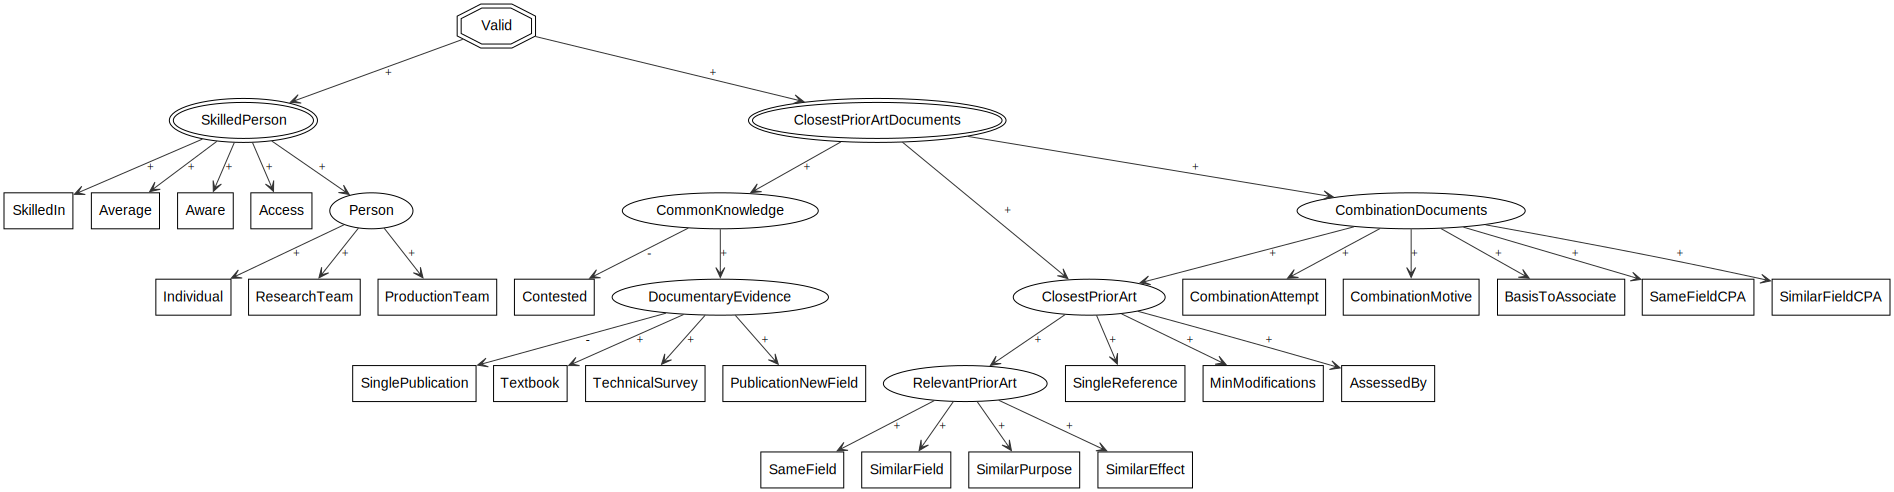

In [2]:
render(adm_initial(), "01_adm_initial")

## 2 — Main ADM — Full (`sub_adm_1=True, sub_adm_2=True`)

  → /mnt/scratch/users/sgdbareh/ADM_JURIX/Analysis/adm_viz/02_adm_main_full.svg


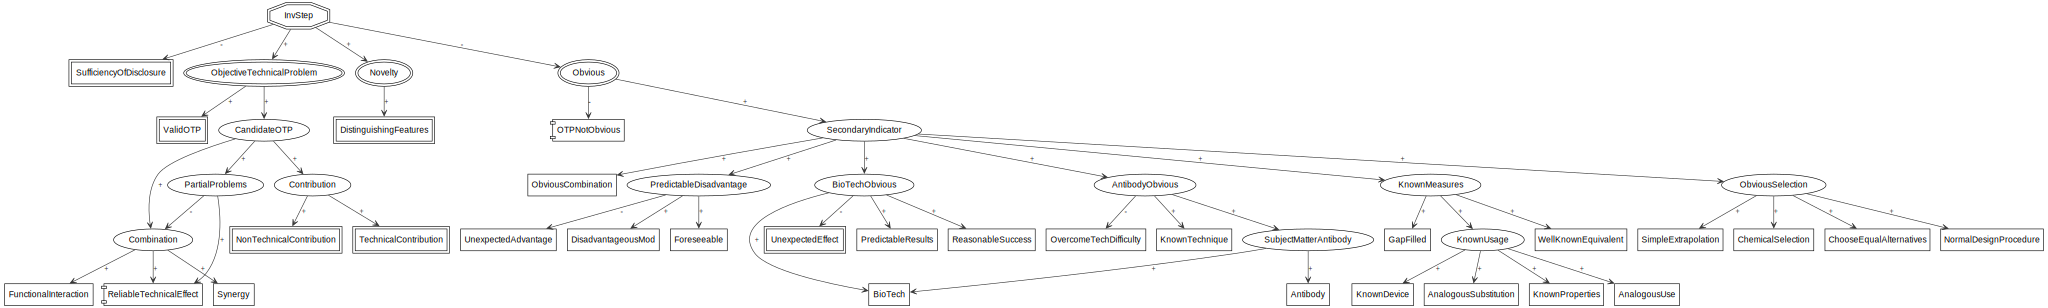

In [3]:
render(adm_main(True, True), "02_adm_main_full")

## 3 — Main ADM — No Sub-ADM 1 (`sub_adm_1=False, sub_adm_2=True`)

  → /mnt/scratch/users/sgdbareh/ADM_JURIX/Analysis/adm_viz/03_adm_main_no_sub1.svg


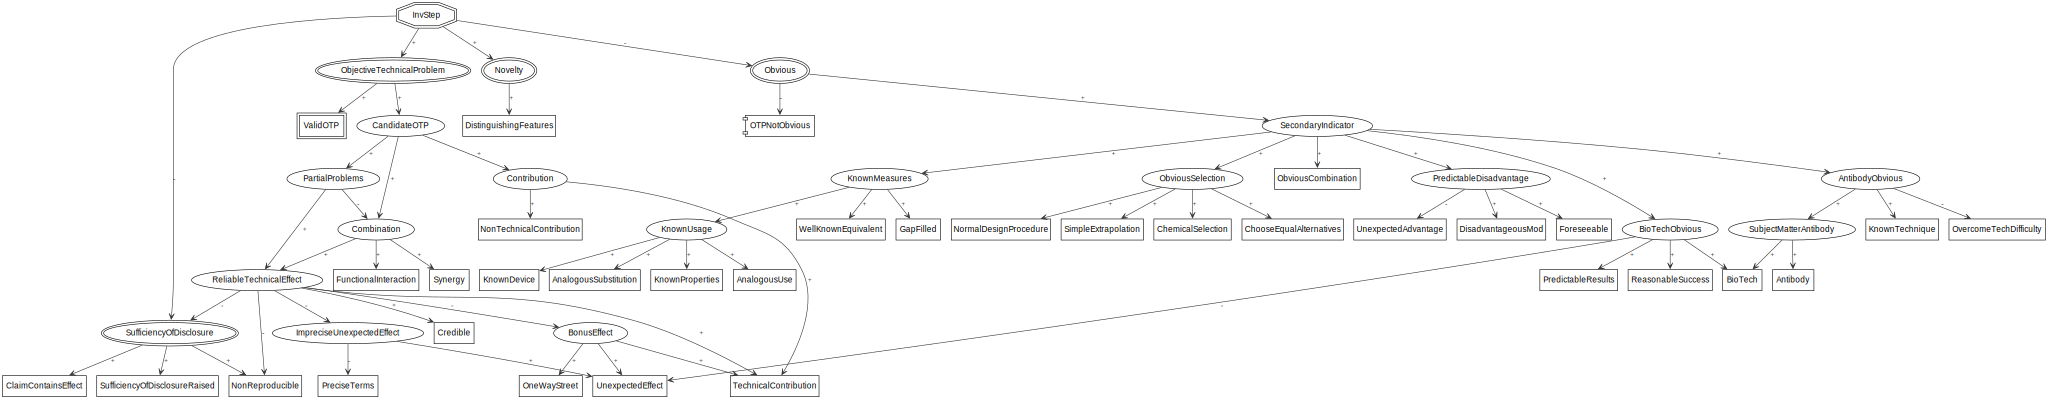

In [4]:
render(adm_main(False, True), "03_adm_main_no_sub1")

## 4 — Main ADM — No Sub-ADM 2 (`sub_adm_1=True, sub_adm_2=False`)

  → /mnt/scratch/users/sgdbareh/ADM_JURIX/Analysis/adm_viz/04_adm_main_no_sub2.svg


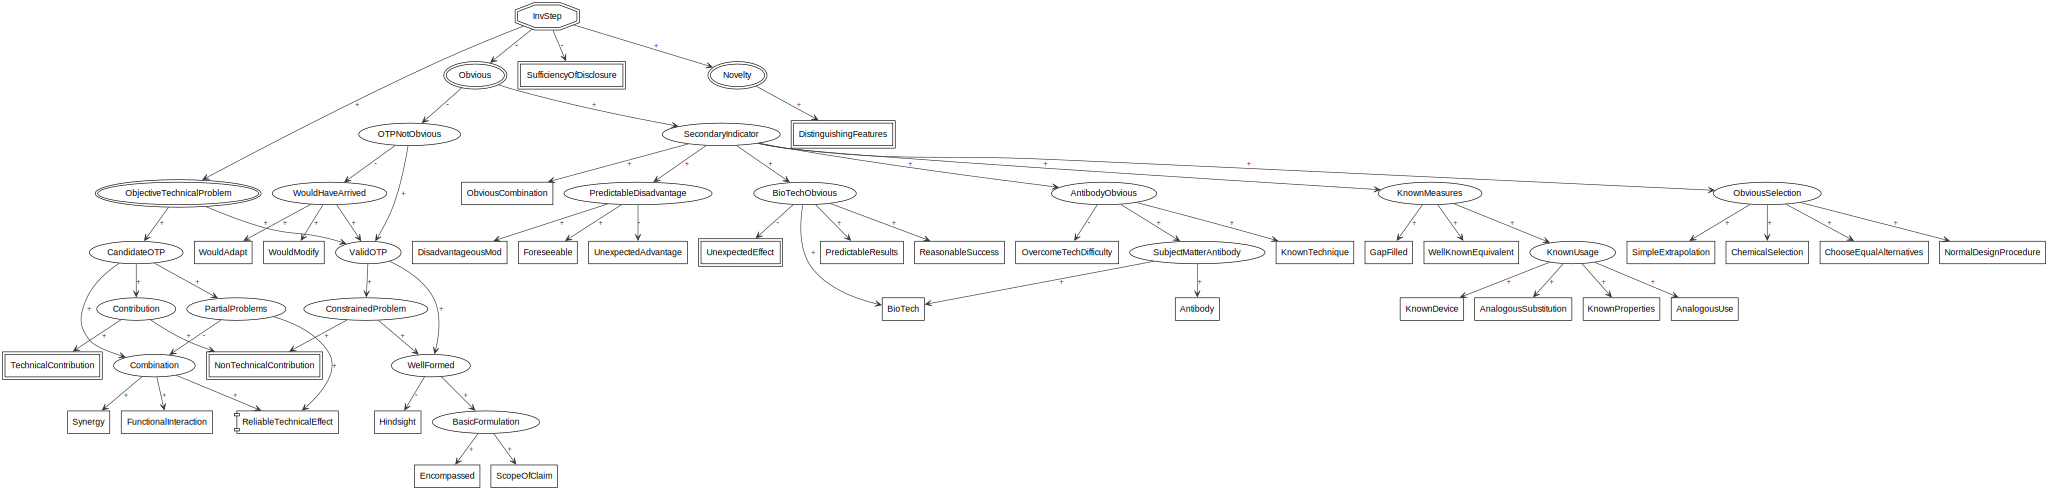

In [5]:
render(adm_main(True, False), "04_adm_main_no_sub2")

## 5 — Main ADM — No Sub-ADMs (`sub_adm_1=False, sub_adm_2=False`)

  → /mnt/scratch/users/sgdbareh/ADM_JURIX/Analysis/adm_viz/05_adm_main_no_both.svg


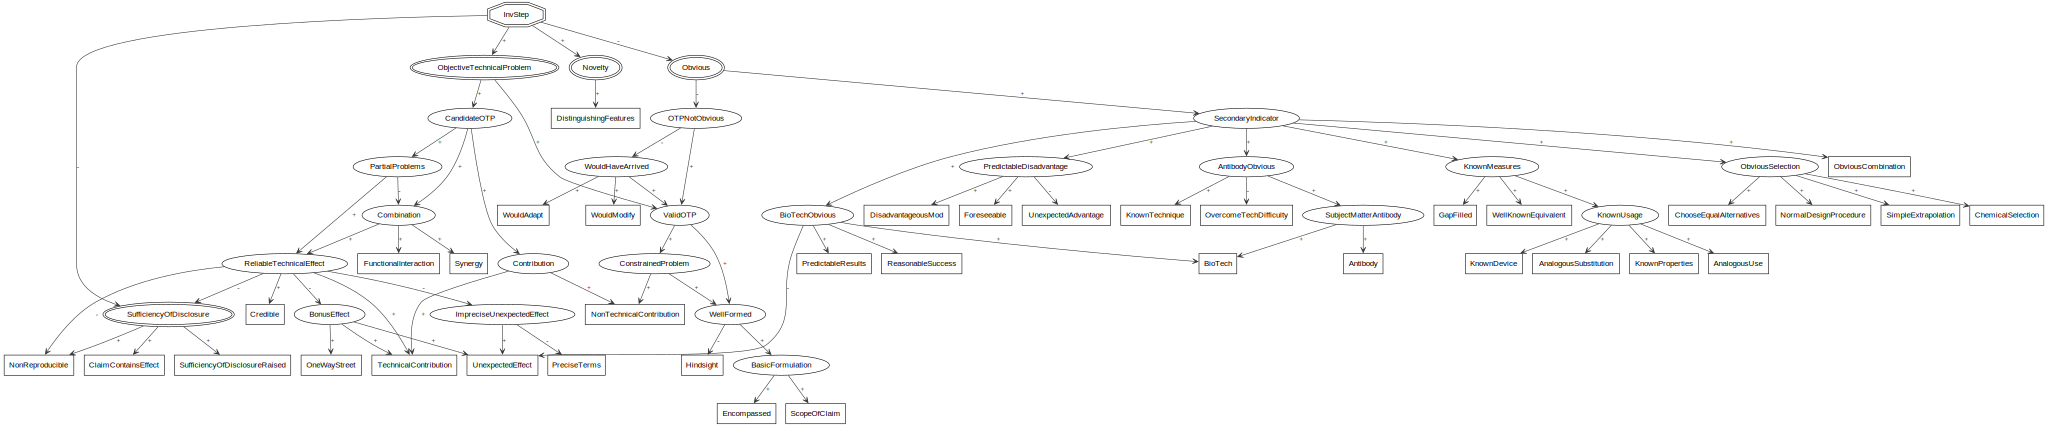

In [6]:
render(adm_main(False, False), "05_adm_main_no_both")

## 6 — Sub-ADM 1: Reliable Technical Effect

  → /mnt/scratch/users/sgdbareh/ADM_JURIX/Analysis/adm_viz/06_sub_adm_1.svg


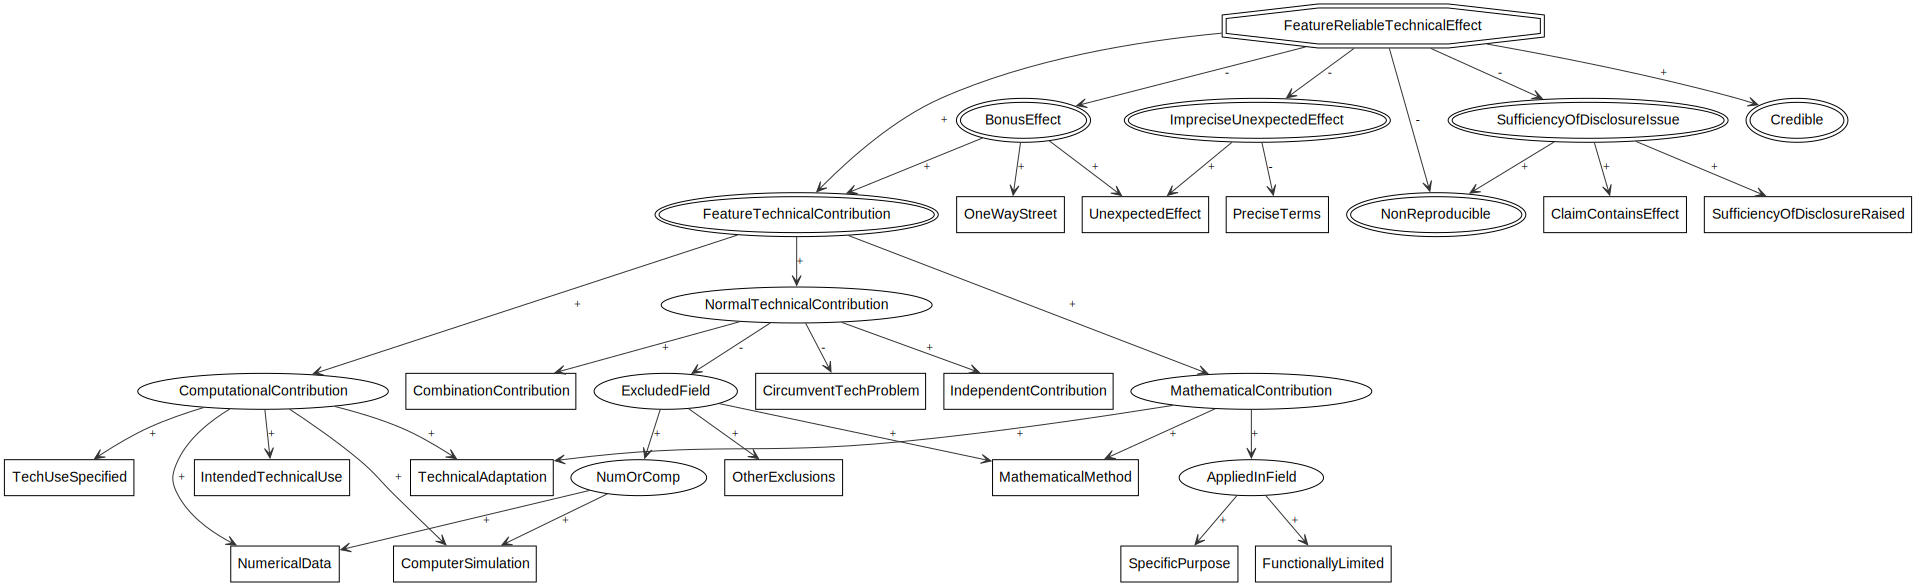

In [7]:
render(sub_adm_1("example_feature"), "06_sub_adm_1")

## 7 — Sub-ADM 2: Objective Technical Problem

  → /mnt/scratch/users/sgdbareh/ADM_JURIX/Analysis/adm_viz/07_sub_adm_2.svg


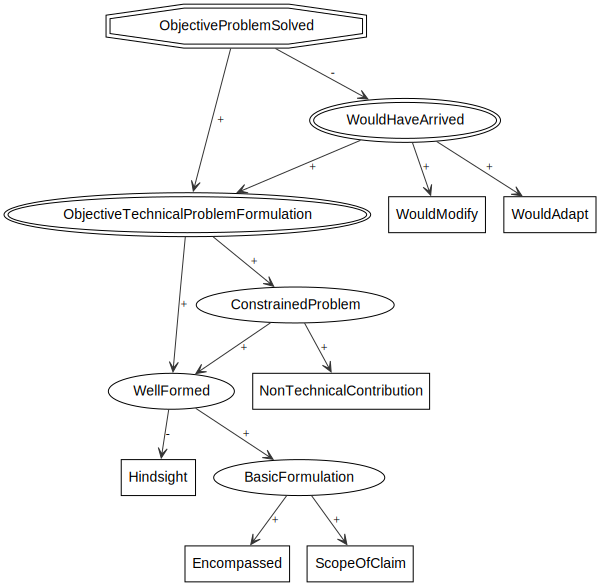

In [8]:
render(sub_adm_2("example_problem"), "07_sub_adm_2")